In [1]:
import gpflow 
import numpy as np
import scipy.stats as ss
from tslearn.metrics import dtw

import matplotlib.pyplot as plt 
import tqdm as tqdm

import sys
sys.path.append("..")

from atmodel import AdaptiveTransferGPR, ConditionalMOGP
from atkernel import TransferKernel, TransferCoregion
from atlikelihood import TransferLikelihood

2025-11-10 17:09:40.188752: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-10 17:09:40.205636: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-10 17:09:40.266119: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-10 17:09:40.266836: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-10 17:09:41.153478: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

(array([533., 289., 224., 218., 172., 185., 136., 150., 134., 155., 146.,
        112., 128., 134., 110., 118., 111., 111., 117., 103.,  89., 110.,
        101., 120., 111.,  91.,  91.,  80., 102., 108.,  83.,  96.,  92.,
        102.,  99.,  93., 106.,  85.,  76.,  91.,  76.,  83.,  93.,  96.,
         79.,  83.,  83.,  87.,  79.,  88.,  75.,  80.,  71.,  80.,  80.,
         72.,  77.,  78.,  93.,  72.,  77.,  72.,  82.,  91.,  73.,  72.,
         90.,  68.,  73.,  82.,  65.,  65.,  61.,  57.,  87.,  74.,  65.,
         75.,  78.,  84.,  73.,  90.,  87.,  76.,  78.,  91., 100.,  86.,
         76.,  66.,  73.,  69.,  87.,  89.,  80.,  62.,  71.,  82.,  68.,
         68.]),
 array([2.37512967e-07, 9.99613905e-03, 1.99920406e-02, 2.99879421e-02,
        3.99838436e-02, 4.99797452e-02, 5.99756467e-02, 6.99715482e-02,
        7.99674498e-02, 8.99633513e-02, 9.99592528e-02, 1.09955154e-01,
        1.19951056e-01, 1.29946957e-01, 1.39942859e-01, 1.49938761e-01,
        1.59934662e-01, 1.6993

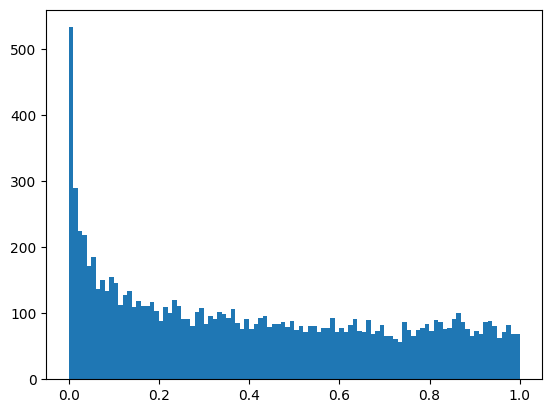

In [2]:
rs = []
for i in range(10000):
    X = np.sort(np.hstack((np.linspace(0, 300, 300).reshape(-1, 1), np.random.choice([0, 1], 300).reshape(-1, 1))), 0)
    k = gpflow.kernels.RBF(active_dims=[0], lengthscales=1, variance=10)
    c = gpflow.kernels.Coregion(2, 1, active_dims=[1])
    kc = k * c
    y = np.random.multivariate_normal(np.zeros_like(X[:,0]), kc(X)).reshape(-1, 1)
    y1 = y[X[:,1] == 0]
    y2 = y[X[:,1] == 1]
    plt.show()


    if len(y1) < len(y2):
        r = ss.pearsonr(y1, y2[:len(y1)])
    else:
        r = ss.pearsonr(y2, y1[:len(y2)])
    rs.append(r)
rs = np.array(rs)
plt.hist(rs[:,1], bins=100)